# Swin Transformer V2 Tiny 
Treino e avaliação de um modelo Swin Transformer V2 Tiny  utilizando imagens reais e geradas por VAE para a classificação de patologias do dataset de CPRE, incluindo análise final via Grad-CAM.

## Imports necessários

In [71]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
from torchvision.models import swin_v2_t, Swin_V2_T_Weights
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score


np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.11.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniconda3/envs/DAA/lib/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.1.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: 6.0.0
TorchVision version: 0.26.0+cu130
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 3.0.2
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: 5.6.2
mlflow version: 3.11.1
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about i

**pth onde o melhor modelo vai ficar**

In [72]:
model_name = './models/swinv2_tiny_VAE_seed0.pth'


**Configuração das seeds para reproducibilidade**

In [73]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)
np.random.seed(0)
set_determinism(seed=0)


## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [74]:
#  Carregamento do Dataset 
base_dir = './dataset_monica'  
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

# Carregar train, val, test dos dados originais
# As imagens geradas pelo VAE so sao adicionadas ao TRAIN para n ter data leakage
for phase in phases:
    load_images_labels(phase)

# Data Augmentation
# Adicionar imagens geradas pelo VAE APENAS ao treino
VAE_GEN_BASE = './vae_generated_perceptual'
vae_classes  = {
    'Biliary_Leaks': 300,  # 110 reais + 300 geradas = 410
    'Normal':        213,  # 197 reais + 213 geradas = 410
    'Stricture':     155,  # 255 reais + 155 geradas = 410
    # Lithiasis: nao adicionamos pq ja tem 505, e a classe maioritaria
    
}

for class_name, n_max in vae_classes.items():
    class_idx = class_names.index(class_name)
    gen_dir   = os.path.join(VAE_GEN_BASE, class_name)
    gen_files = sorted([
        os.path.join(gen_dir, f)
        for f in os.listdir(gen_dir)
        if f.lower().endswith('.png')
    ])[:n_max]
    data['train']['images'].extend(gen_files)
    data['train']['labels'].extend([class_idx] * len(gen_files))
    print(f'VAE {class_name}: {len(gen_files)} imagens adicionadas ao TRAIN')

# Verificar distribuicao final 
for phase in phases:
    labels = data[phase]['labels']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"{phase.upper()} — total: {len(labels)}, por classe: {dict(zip([class_names[u] for u in unique], counts))}")


VAE Biliary_Leaks: 300 imagens adicionadas ao TRAIN
VAE Normal: 213 imagens adicionadas ao TRAIN
VAE Stricture: 155 imagens adicionadas ao TRAIN
TRAIN — total: 1735, por classe: {'Biliary_Leaks': np.int64(410), 'Lithiasis': np.int64(505), 'Normal': np.int64(410), 'Stricture': np.int64(410)}
VAL — total: 234, por classe: {'Biliary_Leaks': np.int64(24), 'Lithiasis': np.int64(98), 'Normal': np.int64(59), 'Stricture': np.int64(53)}
TEST — total: 267, por classe: {'Biliary_Leaks': np.int64(17), 'Lithiasis': np.int64(123), 'Normal': np.int64(43), 'Stricture': np.int64(84)}


## Visualização dos Dados e Gráficos de Distribuição

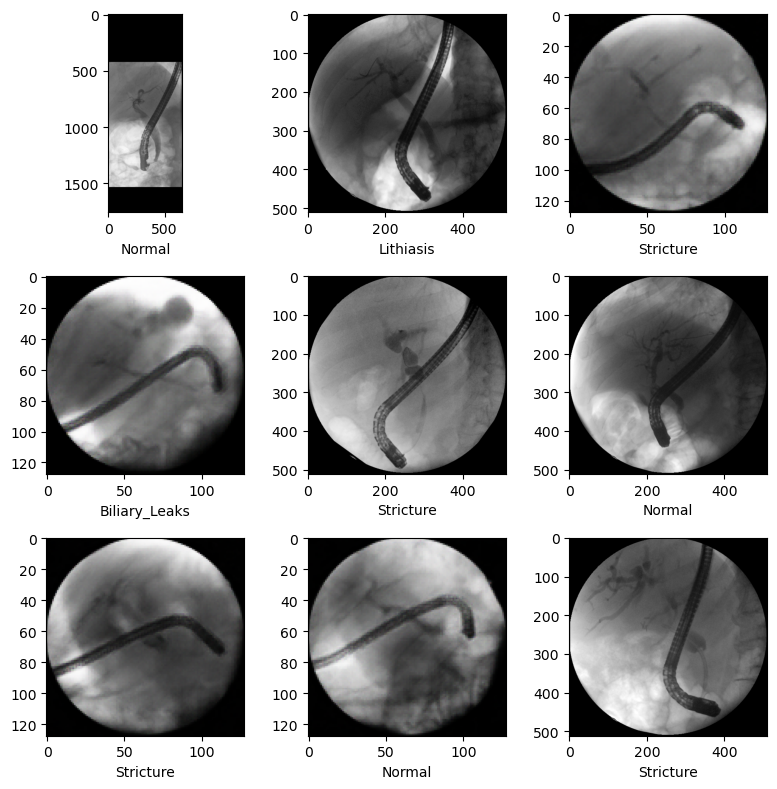

In [5]:
# Amostragem aleatória de 9 imagens do conjunto de treino
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1735
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[410 505 410 410]
1735


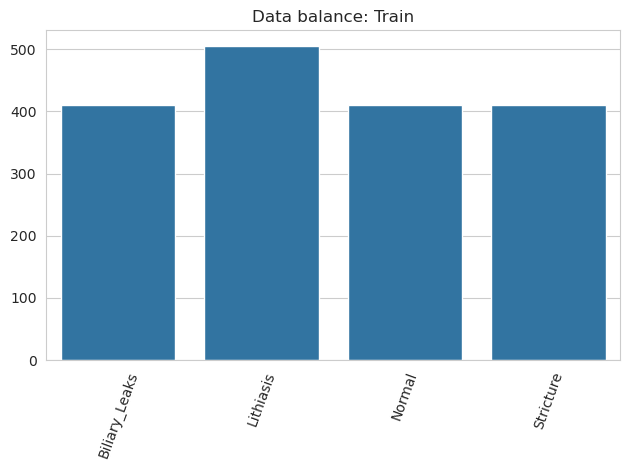

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


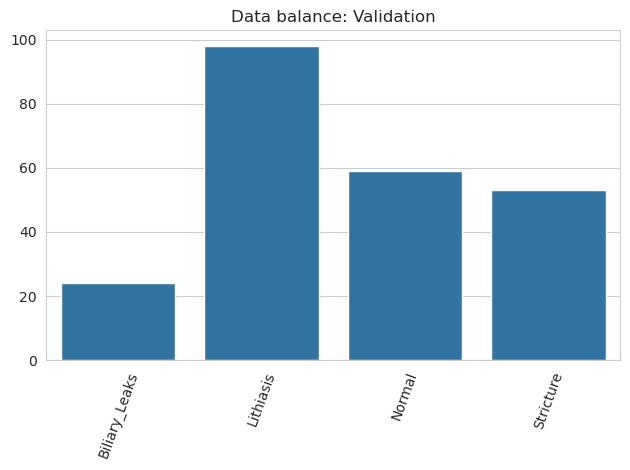

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


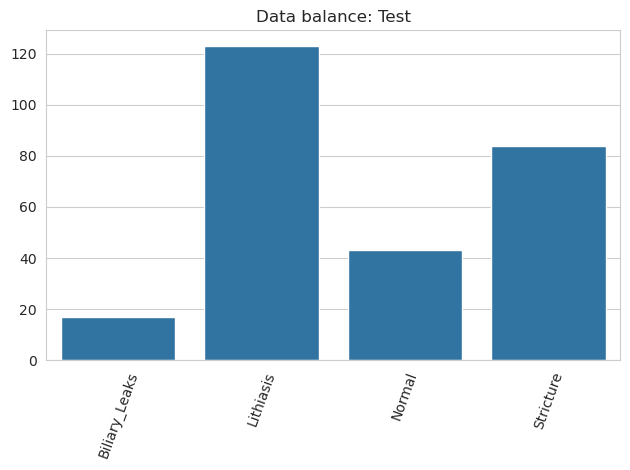

In [6]:
# verificar o balanceamento do holdout
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 256×256.

In [75]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img
    
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((256, 256)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((256, 256)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [76]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=16, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=0)

## Model: SWINV2_TINY_VAE

In [77]:
device = torch.device('cuda:0')
from torchvision.models import swin_v2_t, Swin_V2_T_Weights
# Carregar pesos pré-treinados do Imagenet 
model = swin_v2_t(weights=Swin_V2_T_Weights.IMAGENET1K_V1)

# SwinV2 
model.head = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.head.in_features, num_class)
)
model = model.to(device)
print(f'SwinV2-Tiny carregado. Parametros: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


SwinV2-Tiny carregado. Parametros: 27,585,646


## Training


In [10]:

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 20
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    # F1 metric
    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            #outputs = torch.softmax(outputs, dim=1)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        # Compute F1-score on training set
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()  # Train F1

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                #outputs = torch.softmax(outputs, dim=1)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            # Compute F1-score on validation set
            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            # Estratégia de Saving e Early Stopping baseado no F1 macro de validação
            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()   
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0  # reset counter
            else:
                epochs_without_improvement += 1
            
            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
        
        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()

        scheduler.step() 

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


**Inicialização do Treino**

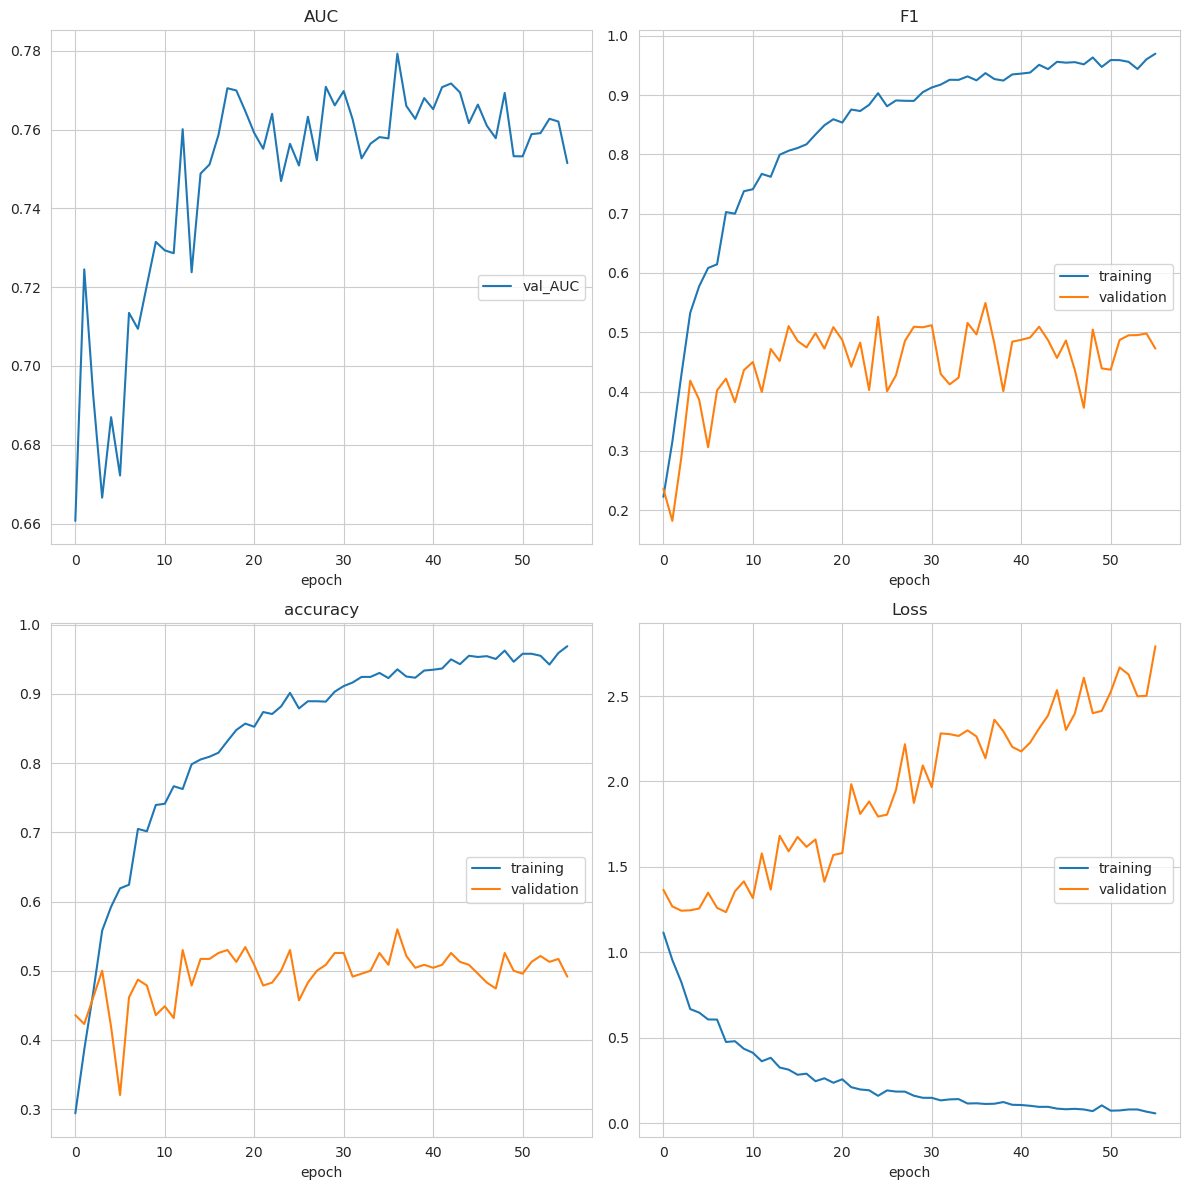

Early stopping at epoch 57 
 Best Val F1: 0.5494 
 Best Train F1: 0.9369 
 current Val F1: 0.4962 
 current Train F1: 0.9629 
 Best epoch: 37 

train completed, best_metric: 0.5494 at epoch: 37
Time elapsed: 2814.66 seconds


In [11]:
import torch
import torch.nn as nn

device = torch.device('cuda')

EPOCHS = 100 
LEARNING_RATE = 2e-5 

class_weights = torch.tensor([6.0, 1.0, 2.0, 1.5], dtype=torch.float32).to(device)

loss_function = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)

val_interval = 1
auc_metric = ROCAUCMetric()

starttime = time.perf_counter()


train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)

endtime = time.perf_counter()
print(f'Time elapsed: {endtime - starttime:.2f} seconds')

## Evaluation
Evaluate the model on the test set, compute F1/accuracy and plot a confusion matrix. The following cells perform inference and generate the final metrics and plots.

F1 Score: 0.6013
true: [0] pred: [0]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [2]
Accuracy: 0.633

correct: 6 incorrect: 5
Accuracy: 0.633

correct: 6 incorrect: 5
F1 Score: 0.6013
               precision    recall  f1-score   support

Biliary_Leaks     0.7778    0.4118    0.5385        17
    Lithiasis     0.6508    0.6667    0.6586       123
       Normal     0.4821    0.6279    0.5455        43
    Stricture     0.6974    0.6310    0.6625        84

     accuracy                         0.6330       267
    macro avg     0.6520    0.5843    0.6013       267
 weighted avg     0.6464    0.6330    0.6340       267

[[ 7  0 10  0]
 [ 0 82 19 22]
 [ 0 15 27  1]
 [ 2 29  0 53]]


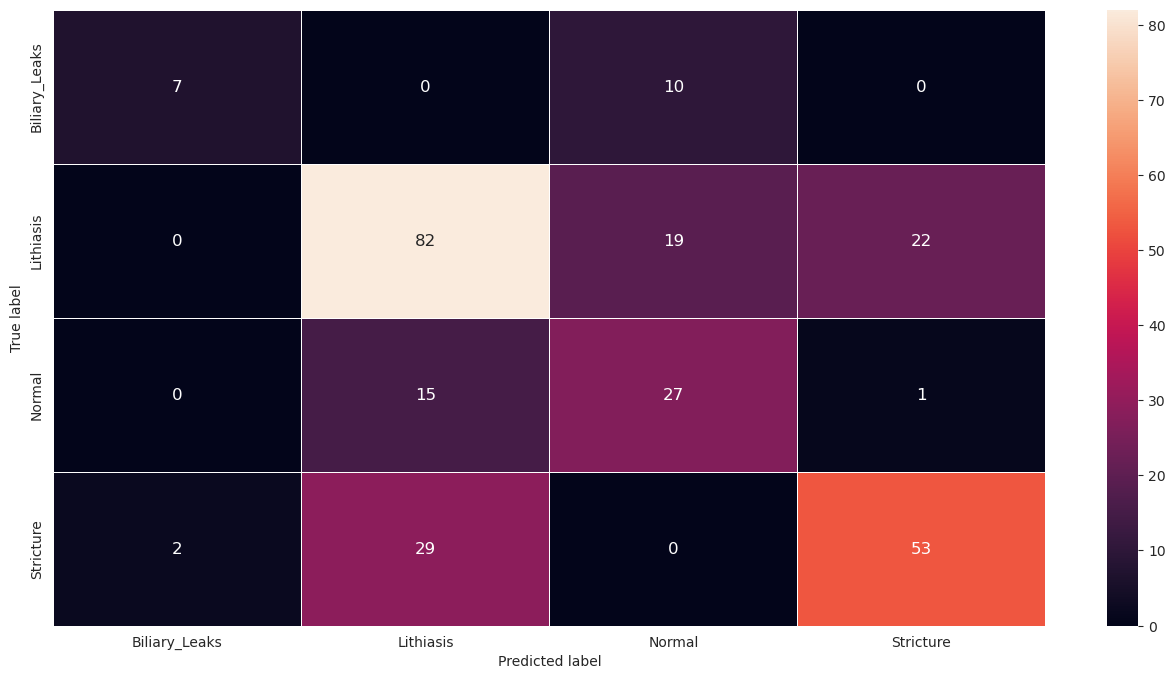

In [12]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    
    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  
    print(f"F1 Score: {f1:0.4f}")
    
    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

# Load trained model
model.load_state_dict(torch.load(model_name, map_location=device))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name)

## Grad-CAM

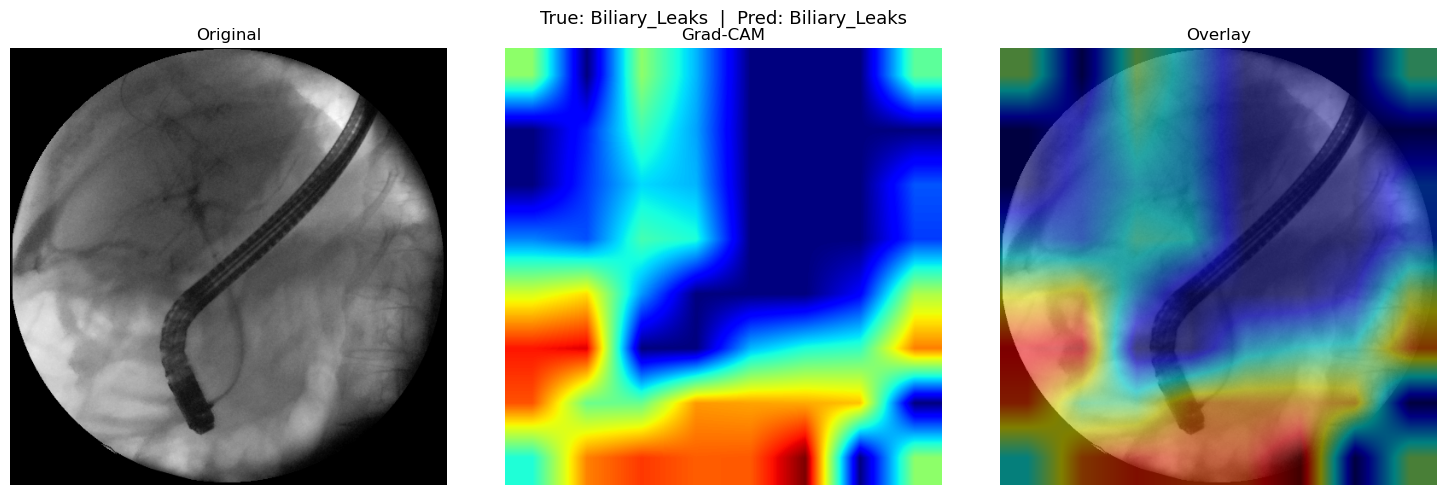

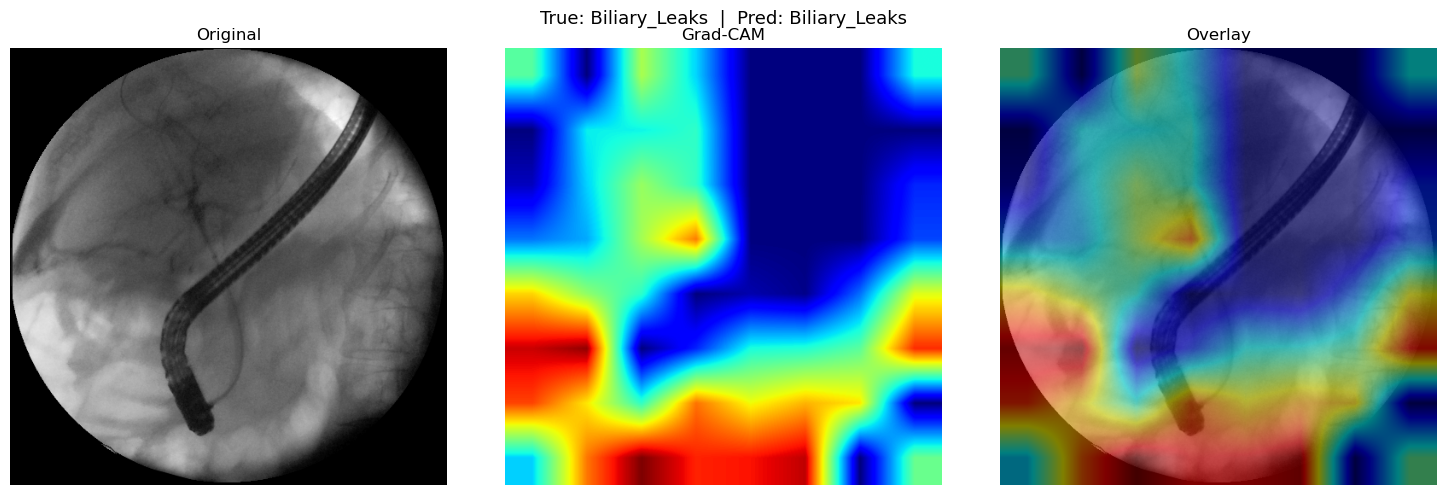

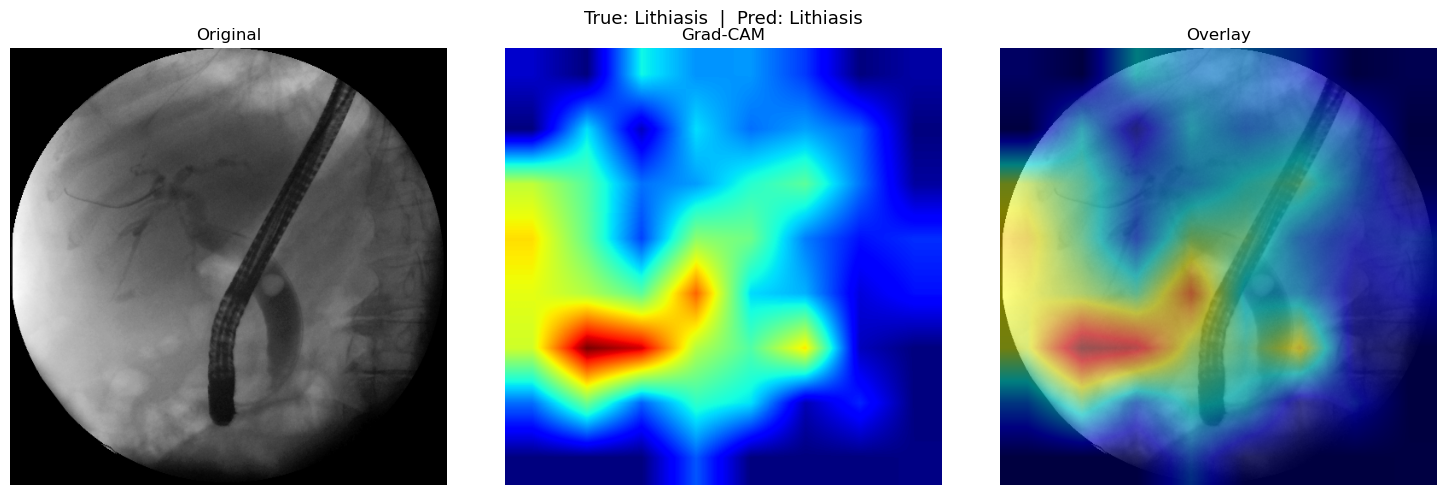

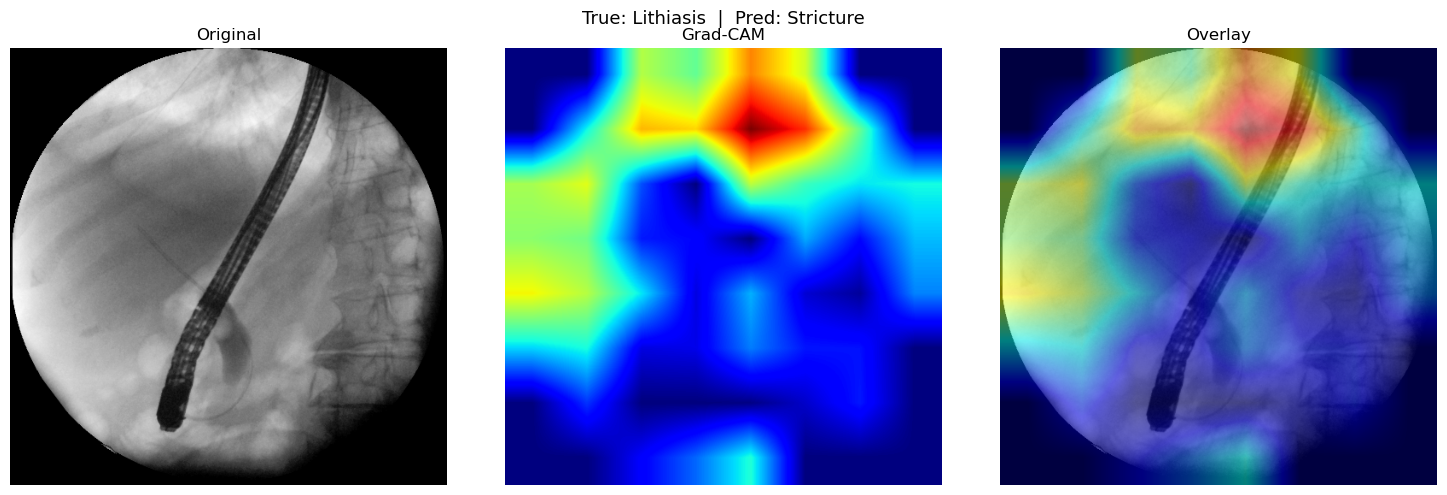

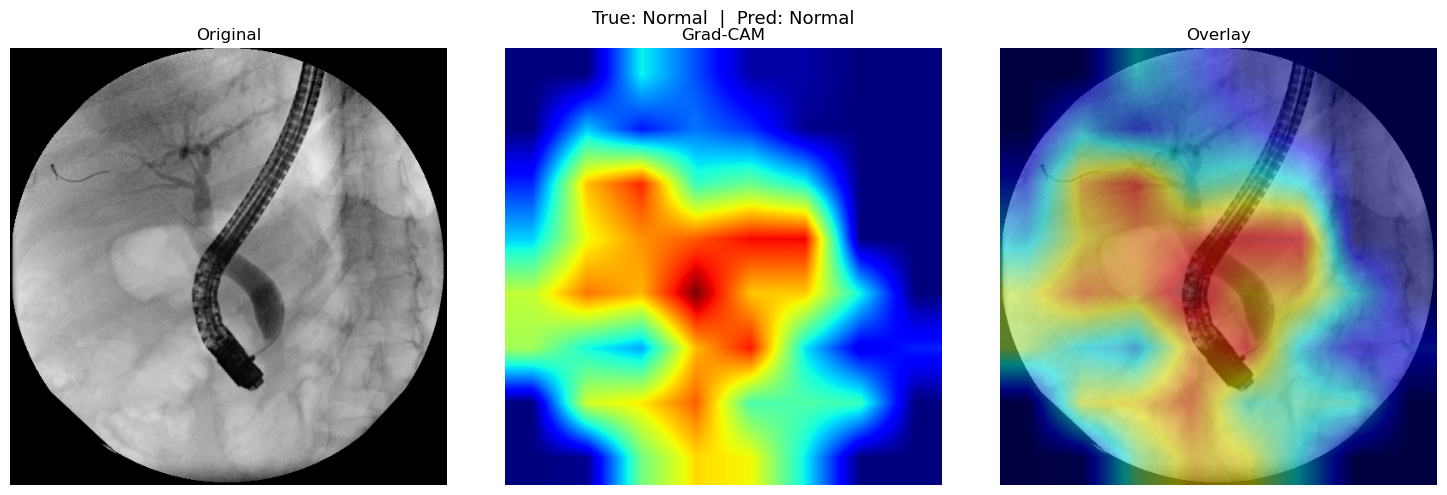

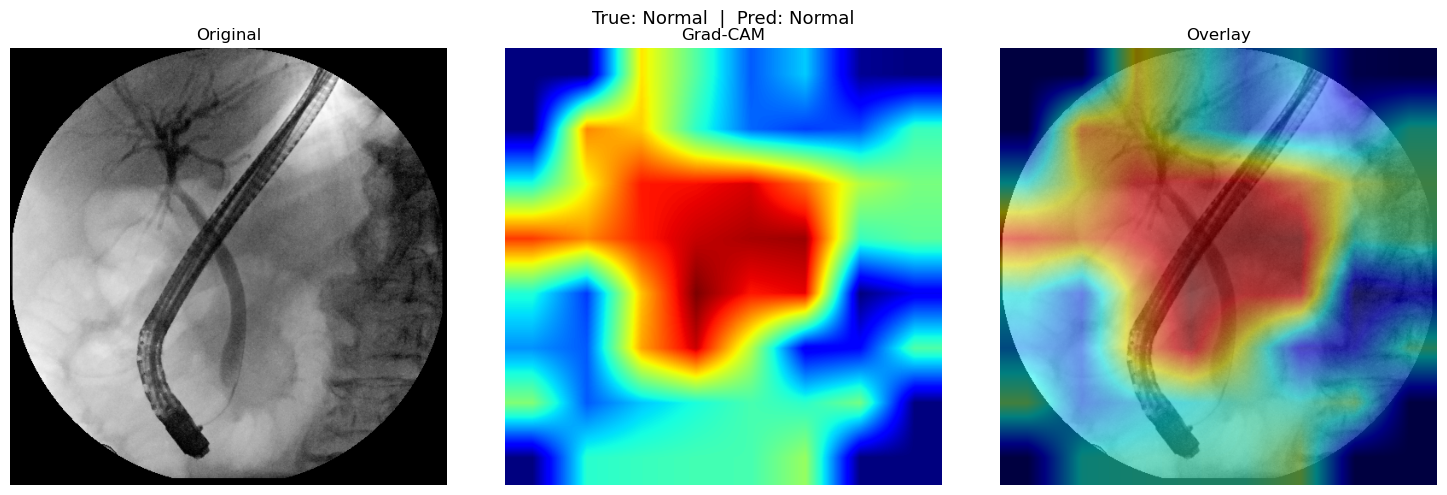

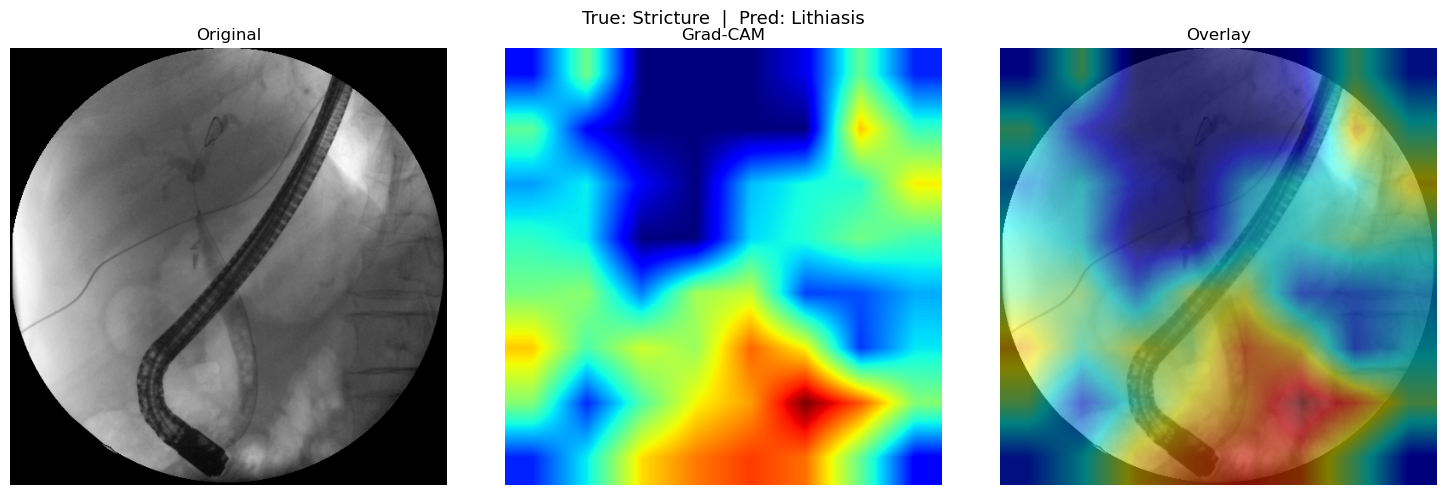

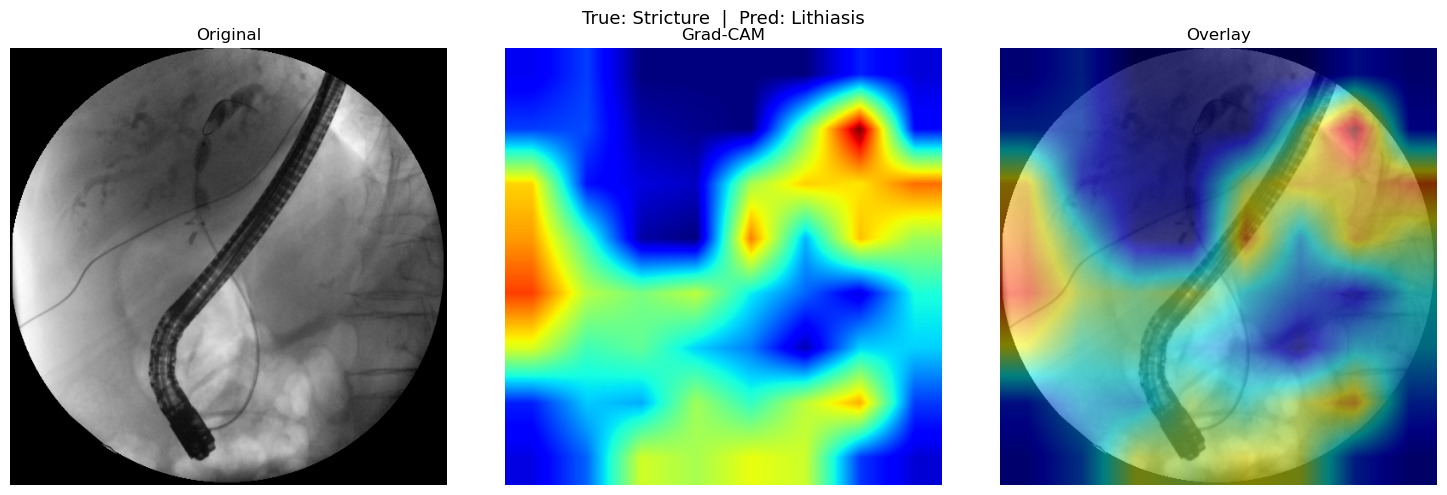

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

model.load_state_dict(torch.load(model_name, map_location=device))
model.eval()

target_layer = model.features[-1]

gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

handle_f = target_layer.register_forward_hook(forward_hook)
handle_b = target_layer.register_full_backward_hook(backward_hook)


def generate_gradcam_transformer(model, img_path, class_idx, transforms):
    """Gera o mapa Grad-CAM adaptado para SwinV2, lidando dinamicamente com shapes 3D ou 4D."""
    gradients.clear()
    activations.clear()

    # Pré-processar imagem
    img_tensor = transforms(img_path).unsqueeze(0).to(device)

    # Forward pass
    model.eval()
    output = model(img_tensor)

    # Backward pass 
    model.zero_grad()
    output[0, class_idx].backward()

    
    grads_raw = gradients[0]
    if isinstance(grads_raw, tuple):
        grads_raw = grads_raw[0]

    acts_raw = activations[0]
    if isinstance(acts_raw, tuple):
        acts_raw = acts_raw[0]

    
    if len(acts_raw.shape) == 4:
        
        B, H_patch, W_patch, C = acts_raw.shape
       
        grads = grads_raw.permute(0, 3, 1, 2)
        acts  = acts_raw.permute(0, 3, 1, 2)
        
    elif len(acts_raw.shape) == 3:
        
        B, L, C = acts_raw.shape
        H_patch = int(np.sqrt(L)) 
        W_patch = H_patch         
        
        grads = grads_raw.permute(0, 2, 1).view(B, C, H_patch, W_patch)
        acts  = acts_raw.permute(0, 2, 1).view(B, C, H_patch, W_patch)
        
    else:
        raise ValueError(f"Formato de ativação inesperado com shape: {acts_raw.shape}")

  
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = cam.squeeze().cpu().detach().numpy()

    # Normalização 
    denom = cam.max() - cam.min()
    if denom == 0:
        denom = 1e-8
    cam = (cam - cam.min()) / denom
    cam = cv2.resize(cam, (512, 512))

    return cam, img_tensor, output

def show_gradcam(img_path, true_label, model, transforms, class_names):
    """Mostra imagem original + heatmap Grad-CAM lado a lado."""
    img_tensor = transforms(img_path).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
    pred_idx = output.argmax(dim=1).item()

    
    cam, _, _ = generate_gradcam_transformer(model, img_path, pred_idx, transforms)

    orig = np.array(Image.open(img_path).convert('RGB').resize((512, 512)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.5 * orig + 0.5 * heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'True: {class_names[true_label]}  |  Pred: {class_names[pred_idx]}', fontsize=13)

    axes[0].imshow(orig)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'gradcam_{class_names[true_label]}_{class_names[pred_idx]}.png', dpi=150)
    plt.show()


n_per_class = 2

for class_idx, class_name in enumerate(class_names):
    class_imgs = [
        path for path, label in zip(data['test']['images'], data['test']['labels'])
        if label == class_idx
    ][:n_per_class]

    for img_path in class_imgs:
        show_gradcam(img_path, class_idx, model, val_transforms, class_names)

# Remover os hooks
handle_f.remove()
handle_b.remove()
